# Modelo Transfer Learning + Fine Tuning

In [7]:
#Importamos librerías e importamos el modelo EfficientNetB7 que ya fue preentrenado

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import models, layers
from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau)

In [8]:
#Cargamos los datos de train, test y las etiquetas que se guardaron en etapas previas

train_img = np.load("train_img.npy")
test_img = np.load("test_img.npy")

train_labels = np.load("train_labels.npy")
test_labels = np.load("test_labels.npy")

class_names = np.load("class_names.npy", allow_pickle=True)

num_classes = len(class_names)


In [ ]:
#Creamos los parámetros de data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
])

In [10]:
#Imprimimos información sobre las clases y sus etiquetas para ver que todo este en orden
print("num_classes:", num_classes)
print("class_names:", class_names)
print("len(class_names):", len(class_names))
print("label mínimo:", train_labels.min())
print("label máximo:", train_labels.max())

num_classes: 18
class_names: ['Ace' 'Akainu' 'Brook' 'Chopper' 'Crocodile' 'Franky' 'Jinbei' 'Kurohige'
 'Law' 'Luffy' 'Mihawk' 'Nami' 'Rayleigh' 'Robin' 'Sanji' 'Shanks' 'Usopp'
 'Zoro']
len(class_names): 18
label mínimo: 0
label máximo: 17


In [24]:
# Cargamos el modelo de Transfer Learning que se guardó y lo preparamos para la etapa de Fine-Tuning
model_ft = tf.keras.models.load_model("best_model_tl.keras")

# Revisamos las capas del modelo
for i, layer in enumerate(model_ft.layers):
    print(i, layer.name, layer.trainable)

# Tomamos la capa EfficientNetB7
base_model = model_ft.layers[3]

# Activamos Fine-Tuning
base_model.trainable = True

# Congelamos todas las capas excepto las últimas 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

# Verificamos cuántas capas quedaron entrenables
trainable_count = 0

for layer in base_model.layers:
    if layer.trainable:
        trainable_count += 1

print("Trainable layers in EfficientNetB7:", trainable_count)

0 sequential True
1 resizing True
2 rescaling_2 True
3 efficientnetb7 False
4 global_average_pooling2d True
5 dense True
6 batch_normalization True
7 dropout True
8 dense_1 True
9 dropout_1 True
10 dense_2 True
Trainable layers in EfficientNetB7: 20


In [ ]:
#Compilamos el modelo 
model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
#Hacemos un checkpoint para guardar el mejor modelo
checkpoint_tl = ModelCheckpoint(
    filepath="best_model_tl_ft.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

#Definimos callbacks por si el modelo deja de mejorar en la etapa de train

early_stop_tl = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_tl = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [15]:
#Entrenamos el modelo
history_ft = model_ft.fit(
    train_img,
    train_labels,
    validation_split=0.2,
    epochs=10,
    batch_size=16,
    callbacks=[checkpoint_tl, early_stop_tl, reduce_lr_tl]
)

Epoch 1/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.5448 - loss: 1.4662
Epoch 1: val_accuracy improved from None to 0.64377, saving model to best_model_tl_ft.keras

Epoch 1: finished saving model to best_model_tl_ft.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 399s 833ms/step - accuracy: 0.5484 - loss: 1.4665 - val_accuracy: 0.6438 - val_loss: 1.1812 - learning_rate: 1.0000e-05
Epoch 2/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.5726 - loss: 1.3970
Epoch 2: val_accuracy improved from 0.64377 to 0.66187, saving model to best_model_tl_ft.keras

Epoch 2: finished saving model to best_model_tl_ft.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 392s 833ms/step - accuracy: 0.5745 - loss: 1.3888 - val_accuracy: 0.6619 - val_loss: 1.1409 - learning_rate: 1.0000e-05
Epoch 3/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.5859 - loss: 1.3687
Epoch 3: val_accuracy improved from 0.66187 to 0.67625, saving model to best_model_tl_ft.keras

Epoch 3: finished saving model to best_

# Métricas

In [20]:
#Cargamos el modelo guardado que tuvo el mejor accurcy durante la etapa de train

best_model_tl_ft = tf.keras.models.load_model("best_model_tl_ft.keras")


#Hacemos predicciones con el modelo para ver como desempeña en el set de test
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

y_pred_probs_tl_ft = best_model_tl_ft.predict(test_img)

y_pred_classes_tl_ft = np.argmax(
    y_pred_probs_tl_ft,
    axis=1
)

accuracy_tl_ft = accuracy_score(
    test_labels,
    y_pred_classes_tl_ft
)

precision_tl_ft = precision_score(
    test_labels,
    y_pred_classes_tl_ft,
    average="weighted"
)

recall_tl_ft = recall_score(
    test_labels,
    y_pred_classes_tl_ft,
    average="weighted"
)

f1_tl_ft = f1_score(
    test_labels,
    y_pred_classes_tl_ft,
    average="weighted"
)

print("Accuracy :", accuracy_tl_ft)
print("Precision:", precision_tl_ft)
print("Recall   :", recall_tl_ft)
print("F1 Score :", f1_tl_ft)

74/74 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step
Accuracy : 0.7163543441226575
Precision: 0.7195398826947208
Recall   : 0.7163543441226575
F1 Score : 0.715776442463632


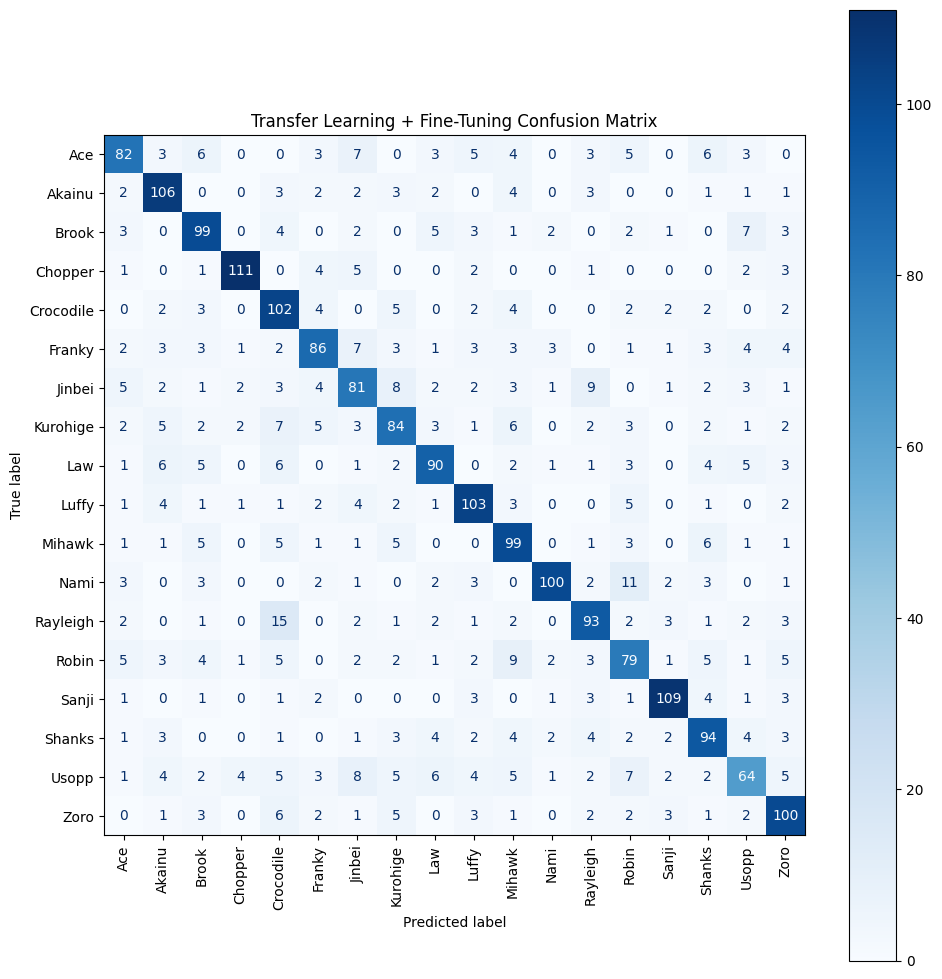

In [22]:
#Calculamos la matriz de confusión para comparar con los modelos anteriores

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    test_labels,
    y_pred_classes_tl_ft
)

fig, ax = plt.subplots(figsize=(10,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90
)

plt.title("Transfer Learning + Fine-Tuning Confusion Matrix")
plt.tight_layout()
plt.show()